# nanoFlow: Introduction to Flow Matching with Rectified Flow

#### Goals:

The goal of this notebook is to familiarize yourself with the following topics:
- **Continuous-time generative models** — Flow Matching and Rectified Flow
- **The flow matching training objective** — learning a velocity field
- **ODE-based sampling** — Euler method for generating new samples
- **Logit-normal timestep sampling** — improved training schedule from Stable Diffusion 3
- **Classifier-free guidance (CFG)** — trading diversity for quality
- **DiT (Diffusion/Flow Transformer) architecture** — Transformer-based denoiser

This notebook is organized in two main parts:
- **Part I (Training)** — Understand the training procedure and implement it
- **Part II (Inference)** — Understand the sampling procedure and implement it

#### Instructions:

Fill in the missing code in `nanofm/modeling/dit.py` and `nanofm/models/rectified_flow.py` (highlighted by `???`), then run the training and evaluation cells in this notebook.

---

## 1 Setup

### 1.1 Imports

In [1]:
import os
import sys
import numpy as np

# Set working directory to project root (parent of notebooks/)
current_folder = globals()['_dh'][0]
project_root = os.path.dirname(os.path.abspath(current_folder))
os.chdir(project_root)
sys.path.insert(0, project_root)

import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from tqdm.auto import tqdm
from PIL import Image


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


---

## 2 Background: What is Flow Matching?

### 2.1 The Big Picture

Generative models aim to learn a mapping from a simple distribution (like Gaussian noise) to a complex data distribution (like images). There are many approaches:

| Approach | Key Idea |
|----------|----------|
| **GANs** | Train a generator and discriminator adversarially |
| **VAEs** | Learn an encoder-decoder with a latent space |
| **Autoregressive** | Generate tokens one at a time (GPT) |
| **Diffusion Models** | Gradually add noise, then learn to denoise |
| **Flow Matching** | Learn a velocity field that transports noise → data |

**Flow Matching** (and its variant **Rectified Flow**) is a recent and elegant approach that has powered state-of-the-art image generators like [Stable Diffusion 3](https://arxiv.org/abs/2403.03206) and [Flux](https://github.com/black-forest-labs/flux).

The key idea: instead of the complex stochastic process used in diffusion models, we define a **straight-line path** from data to noise and learn the **velocity** along this path.

*The core problem: learn a **transport map** that moves samples from an easy noise distribution*
*to a complex data distribution. Flow matching learns this map as a velocity field.*

![Noise to data transport map](./assets/nanoFlow_noise_to_data.gif)


### 2.2 Rectified Flow: Straight-Line Paths

Given a data sample $x_0$ and noise $x_1 \sim \mathcal{N}(0, I)$, **Rectified Flow** defines a **straight-line interpolation**:

$$z_t = (1 - t) \cdot x_0 + t \cdot x_1, \quad t \in [0, 1]$$

- At $t = 0$: $z_0 = x_0$ (clean data)
- At $t = 1$: $z_1 = x_1$ (pure noise)
- At $t = 0.5$: a mixture of half data and half noise

The **velocity** (rate of change) along this path is simply:

$$v = \frac{dz_t}{dt} = x_1 - x_0$$

We train a neural network $v_\theta(z_t, t)$ to predict this velocity at any point along the path. The whole framework has just **two phases**:

| Phase | What happens |
|-------|-------------|
| **Training** | Given data, learn to predict the velocity field |
| **Inference** | Starting from noise, follow the learned velocity field back to data |

Let's explore each phase in detail.

---

# Part I: Training — Learning the Velocity Field

In this part we will:
1. Understand how training data is mixed with noise (the forward process)
2. Define the training loss
3. Learn about logit-normal time sampling
4. Meet the DiT-LLaMA model architecture
5. Implement the training code (Exercises 1–3)
6. Train a model on MNIST

## 3 The Forward Process (Interpolation)

During **training**, we need pairs of (noisy input, target velocity). We create them by interpolating between a real data sample and random noise:

$$z_t = (1 - t) \cdot x_0 + t \cdot x_1, \quad x_1 \sim \mathcal{N}(0, I)$$

The target velocity is the direction from data to noise: $v = x_1 - x_0$.

Let's visualize what this interpolation looks like for a real MNIST digit:

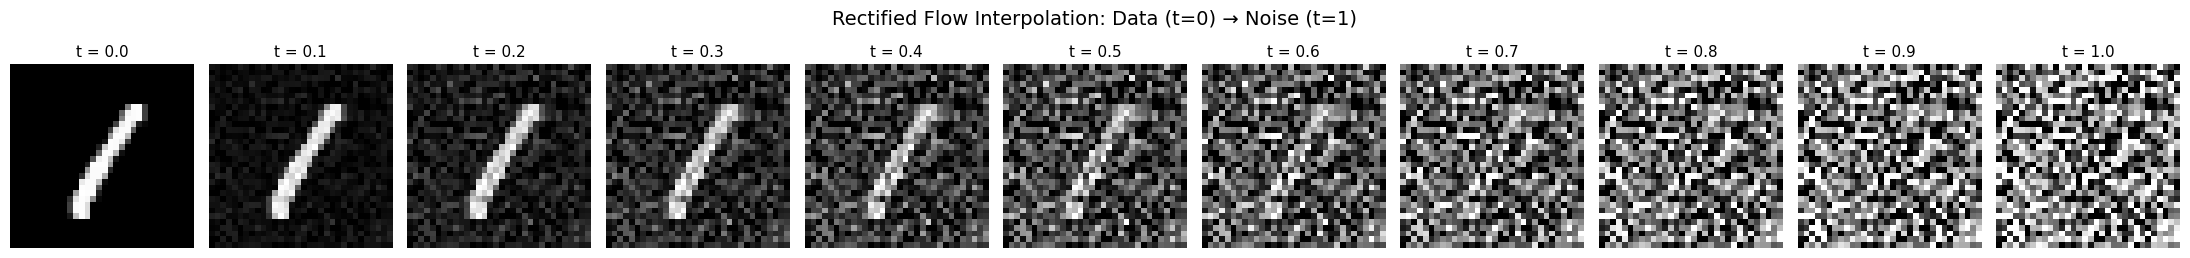

At t=0 we have the clean digit. At t=1 we have pure noise.
The model learns to predict the velocity v = x1 - x0 at any point z_t along this path.


In [2]:
# Load a sample MNIST image
transform_viz = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize((0.5,), (0.5,)),
])
mnist_viz = datasets.MNIST(root="./data", train=True, download=True, transform=transform_viz)

# Pick a clean image x0 and sample noise x1
x0 = mnist_viz[3][0].unsqueeze(0)  # shape: (1, 1, 32, 32)
x1 = torch.randn_like(x0)          # noise with same shape

# Visualize the interpolation at different timesteps
timesteps = np.linspace(0, 1, 11)
fig, axes = plt.subplots(1, 11, figsize=(22, 2.5))
for i, t in enumerate(timesteps):
    zt = (1 - t) * x0 + t * x1
    img = zt[0, 0].numpy() * 0.5 + 0.5  # unnormalize to [0, 1]
    axes[i].imshow(img.clip(0, 1), cmap='gray')
    axes[i].set_title(f't = {t:.1f}', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Rectified Flow Interpolation: Data (t=0) → Noise (t=1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print("At t=0 we have the clean digit. At t=1 we have pure noise.")
print("The model learns to predict the velocity v = x1 - x0 at any point z_t along this path.")

*Each particle follows a straight-line path $z_t = (1-t)\,x_0 + t\,x_1$ — 
what you implement in **§7.2**. Colour shifts from blue to red/green as the destination cluster becomes clear.*

![Distribution transport animation](./assets/nanoFlow_transport.gif)


## 4 The Training Objective

The training loss is a simple **mean squared error (MSE)** between the predicted and true velocity:

$$\mathcal{L} = \mathbb{E}_{t,\, x_0 \sim p_{\text{data}},\, x_1 \sim \mathcal{N}(0,I)} \left[ \left\| v_\theta(z_t, t) - (x_1 - x_0) \right\|^2 \right]$$

where $z_t = (1-t) \cdot x_0 + t \cdot x_1$.

**Each training step:**
1. Sample a batch of data $x_0$ from the dataset
2. Sample random noise $x_1 \sim \mathcal{N}(0, I)$
3. Sample random timesteps $t$ for each sample
4. Compute the interpolation $z_t = (1-t) \cdot x_0 + t \cdot x_1$
5. Predict the velocity $v_\theta(z_t, t)$
6. Minimize the MSE: $\|v_\theta - (x_1 - x_0)\|^2$

This is remarkably simple compared to diffusion models — no noise schedules, no variance parameterization, just straight-line interpolation and MSE.

*Five panels show $p_t$ at $t \in \{0, 0.25, 0.5, 0.75, 1\}$. 
The highlighted panel sweeps left→right. 
The velocity target you predict in **§7.3** is $u_t = x_1 - x_0$ — 
constant for all $t$ along a linear path.*

![Snapshot strip animation](./assets/nanoFlow_snapshots.gif)


## 5 Logit-Normal Time Sampling

During training, we need to sample timesteps $t$. The simplest approach is **uniform** sampling:
$$t \sim \mathcal{U}(0, 1)$$

However, [Stable Diffusion 3 (Esser et al., 2024)](https://arxiv.org/abs/2403.03206) found that using a **logit-normal** distribution improves training. The procedure is:

1. Sample $n \sim \mathcal{N}(0, 1)$
2. Set $t = \sigma(n) = \frac{1}{1 + e^{-n}}$

This concentrates more training effort on **intermediate timesteps** (around $t = 0.5$), where the prediction task is arguably the hardest — the input is a challenging mix of signal and noise.

Let's visualize the difference:

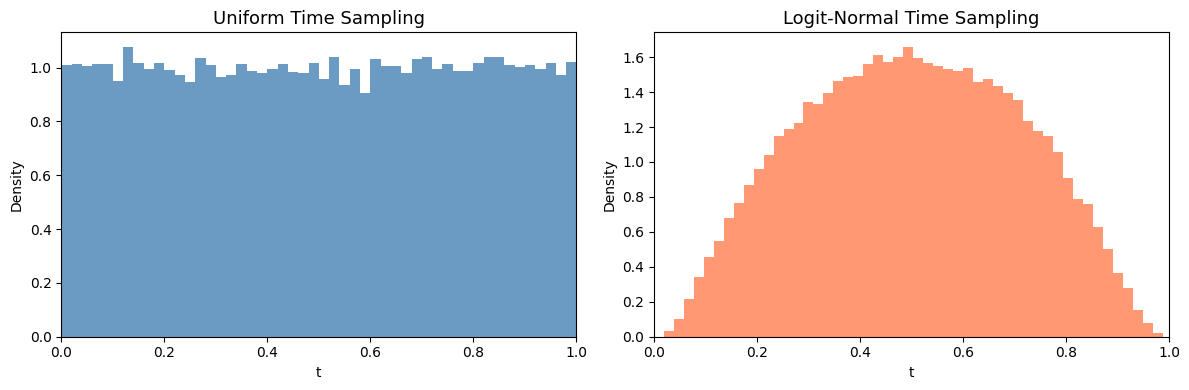

Logit-normal sampling focuses more training on intermediate timesteps (around t=0.5),
where the denoising task is arguably the most challenging.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Uniform sampling
t_uniform = torch.rand(50000)
axes[0].hist(t_uniform.numpy(), bins=50, density=True, color='steelblue', alpha=0.8)
axes[0].set_title('Uniform Time Sampling', fontsize=13)
axes[0].set_xlabel('t')
axes[0].set_ylabel('Density')
axes[0].set_xlim(0, 1)

# Logit-normal sampling
nt = torch.randn(50000)
t_logit_normal = torch.sigmoid(nt)
axes[1].hist(t_logit_normal.numpy(), bins=50, density=True, color='coral', alpha=0.8)
axes[1].set_title('Logit-Normal Time Sampling', fontsize=13)
axes[1].set_xlabel('t')
axes[1].set_ylabel('Density')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()
print("Logit-normal sampling focuses more training on intermediate timesteps (around t=0.5),")
print("where the denoising task is arguably the most challenging.")

## 6 Exercises — DiT-LLaMA Architecture (40 points)

We use a **Diffusion Transformer (DiT)** with a LLaMA-style architecture as the velocity prediction network $v_\theta$. This is the neural network that will be **trained** to predict the velocity field. Here's a high-level overview:

```
Input Image (B, C, H, W)
    │
    ▼
Initial Conv Layers          ← Shallow feature extraction
    │
    ▼
Patchify + Linear Embed      ← Convert spatial features to patch tokens
    │
    ▼
┌─────────────────────┐
│  Transformer Block  │ ×N   ← Self-attention + FFN with AdaLN modulation
│  (with RoPE + AdaLN)│      ← Timestep & class info injected via AdaLN
└─────────────────────┘
    │
    ▼
Final Layer (AdaLN + Linear) ← Project back to patch space
    │
    ▼
Unpatchify                   ← Reconstruct spatial output
    │
    ▼
Predicted Velocity (B, C, H, W)
```

**Key components:**
- **Timestep Embedder**: Sinusoidal positional encoding → MLP, maps scalar $t$ to a feature vector
- **Label Embedder**: Learned class embedding (with dropout for CFG training)
- **AdaLN (Adaptive Layer Normalization)**: Modulates features using timestep + class info (shift, scale, gate)
- **RoPE (Rotary Position Embedding)**: Encodes spatial position in the attention mechanism
- **SwiGLU Feed-Forward**: LLaMA-style gated FFN

The model takes `(noisy_image, timestep, class_label)` and outputs the predicted velocity field.

### 6.1 `modulate()` (5 points)

In `nano4M/nanofm/modeling/dit.py`, implement the `modulate` helper function.
AdaLN conditions the layer norms by affine-transforming their output with a learned
**shift** and **scale** derived from the conditioning signal (timestep + class label):

$$\text{modulate}(x, \text{shift}, \text{scale}) = x \cdot (1 + \text{scale}) + \text{shift}$$


### 6.2 `LabelEmbedder.token_drop()` (5 points)

In `nano4M/nanofm/modeling/dit.py`, implement the CFG label dropout inside `LabelEmbedder.token_drop()`.
During training, some fraction of class labels are randomly replaced with a special
*null* token (index `self.num_classes`) so that the model also learns unconditional
generation — a requirement for classifier-free guidance at inference time (see Section 10).

Randomly sample a boolean drop mask based on `self.dropout_prob`, ensure it is on
the correct device, and use it to replace dropped label positions with `self.num_classes`.


### 6.3 `TransformerBlock.forward()` with AdaLN (15 points)

In `nano4M/nanofm/modeling/dit.py`, implement the AdaLN-conditioned path of `TransformerBlock.forward()`.
This is the heart of the DiT architecture. When `adaln_input` is provided, each
Transformer block conditions its layer norms using the timestep + class signal.

Use `self.adaLN_modulation` to produce shift, scale, and gate parameters for both
the attention and FFN sub-layers. For each sub-layer: normalize the input, apply
AdaLN modulation with the corresponding shift and scale, pass through the sub-layer,
gate the output, and add it as a residual.

When `adaln_input is None`, the block reduces to a standard pre-norm Transformer
block (already given to you — same structure as what you built in Part 1).


### 6.4 `FinalLayer.forward()` (5 points)

In `nano4M/nanofm/modeling/dit.py`, implement `FinalLayer.forward()`.
It applies one last round of AdaLN modulation before projecting each patch token
back to pixel space.

Derive shift and scale from the conditioning vector `c`, apply AdaLN modulation
to the normalized token sequence, then project to the output patch dimension.


### 6.5 `DiT_Llama.forward()` (15 points)

In `nano4M/nanofm/modeling/dit.py`, implement `DiT_Llama.forward()`.
Looking at the architecture diagram above and the model's attributes, implement
the complete forward pass that:

1. Applies shallow convolutional feature extraction to the input image
2. Converts the resulting feature maps into a sequence of patch tokens and
   projects them to the transformer hidden dimension
3. Embeds the scalar timestep and the class label, then combines them into
   a single conditioning vector for AdaLN
4. Passes the token sequence through all transformer layers, supplying the
   appropriate rotary position frequencies and the conditioning vector
5. Projects patch tokens back to pixel space via the final layer
6. Reconstructs the full spatial output from patch tokens

Inspect the class attributes and the architecture components already defined
(embedders, patchify/unpatchify, `self.layers`, `self.freqs_cis`,
`self.final_layer`) to understand how to wire these stages together.


### 6.6 DiT Sanity Check (5 points)

After filling in Sections 6.1–6.5, run the cell below to verify the DiT model's
forward pass. Include the output (showing a successful assertion) in your submission.


In [4]:
# Reload dit.py in case you made changes
import importlib
import nanofm.modeling.dit as dit_mod

importlib.reload(dit_mod)
DiT_Llama = dit_mod.DiT_Llama

# Create a small DiT model and run a forward pass
test_dit = DiT_Llama(
    in_channels=1, input_size=32,
    dim=64, n_layers=2, n_heads=4, num_classes=10
)

with torch.no_grad():
    x_dit = torch.randn(2, 1, 32, 32)
    t_dit = torch.rand(2)
    y_dit = torch.randint(0, 10, (2,))
    out_dit = test_dit(x_dit, t_dit, y_dit)

assert out_dit.shape == x_dit.shape, \
    f"Expected output shape {x_dit.shape}, got {out_dit.shape}"
print(f"DiT forward pass OK! Input: {x_dit.shape} -> Output: {out_dit.shape}")

del test_dit
print("\n✓ DiT sanity check passed! Proceed to Section 7 (Exercises 7.1–7.3) for the training loop.")

DiT forward pass OK! Input: torch.Size([2, 1, 32, 32]) -> Output: torch.Size([2, 1, 32, 32])

✓ DiT sanity check passed! Proceed to Section 7 (Exercises 7.1–7.3) for the training loop.


## 7 Exercises — Training (30 points)

Open `nano4M/nanofm/models/rectified_flow.py` and fill in **Sections 7.1–7.3**
inside the `forward` method.


### 7.1 Sample timesteps (10 points)

Implement timestep sampling inside `RectifiedFlow.forward()`:

- If `self.ln` is `True`: use the logit-normal reparameterisation — sample from a
  standard normal and transform it to the $(0, 1)$ range
- Otherwise: sample `t` uniformly from $[0, 1]$
- Ensure `t` has shape `(b,)` and lives on the same device as `x`


### 7.2 Compute interpolated samples (10 points)

Implement the forward (noising) process:

- Sample noise `z1` from $\mathcal{N}(0, I)$ with the same shape as `x`
- Compute the linearly interpolated sample `zt` between clean data and noise
  at time `texp` (use `texp` for correct broadcasting with spatial dimensions)


### 7.3 Predict velocity and compute loss (10 points)

Using the interpolated sample `zt`, the timestep `t`, and the class conditioning
`cond`, run the model forward pass to obtain the predicted velocity.

Recall that the rectified flow training target is the straight-line velocity
from noise to data. Compute the per-sample MSE between the predicted velocity
and the target velocity, averaging over all non-batch dimensions (C, H, W)
while keeping the batch dimension intact for the weighting step that follows.


### 7.4 Training Sanity Check

After filling in Sections 7.1–7.3, run the cell below to verify the **training**
forward and backward passes work correctly.


In [5]:
# Reload the module in case you made changes
import importlib
import nanofm.models.rectified_flow as rf_mod
importlib.reload(rf_mod)
RectifiedFlow = rf_mod.RectifiedFlow

# Create a small test model
test_model = DiT_Llama(
    in_channels=1, input_size=32,
    dim=64, n_layers=2, n_heads=4, num_classes=10
).to(device)

rf_test = RectifiedFlow(test_model, ln=True)

# Test forward pass (training)
x_test = torch.randn(4, 1, 32, 32).to(device)
c_test = torch.randint(0, 10, (4,)).to(device)
loss, ttloss = rf_test.forward(x_test, c_test)
print(f"Forward pass OK! Loss: {loss.item():.4f}")
assert loss.ndim == 0, "Loss should be a scalar"
assert loss.item() > 0, "Loss should be positive"

# Test backward pass
loss.backward()
print("Backward pass OK!")

del test_model, rf_test  # Free memory
print("\n✓ Training sanity checks passed! You can proceed to train on MNIST.")

Forward pass OK! Loss: 2.0062


Backward pass OK!

✓ Training sanity checks passed! You can proceed to train on MNIST.


## 8 Training on MNIST

Now let's train a Rectified Flow model on MNIST! We use a small DiT-LLaMA model that should train in just a few minutes on a single GPU.

### 8.1 Data and Model Setup

In [6]:
# Hyperparameters
NUM_EPOCHS = 30      # Number of training epochs (increase for better results)
BATCH_SIZE = 256     # Batch size
LEARNING_RATE = 5e-4 # Adam learning rate
USE_LOGIT_NORMAL = True  # Use logit-normal time sampling

# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),                     # 28x28 -> 32x32
    transforms.Normalize((0.5,), (0.5,)),  # [0,1] -> [-1,1]
])
mnist = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataloader = DataLoader(mnist, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Dataset size: {len(mnist)} images")
print(f"Number of batches per epoch: {len(dataloader)}")
print(f"Image shape: {mnist[0][0].shape} (channels, height, width)")

# Model
model = DiT_Llama(
    in_channels=1,
    input_size=32,
    patch_size=2,
    dim=64,
    n_layers=6,
    n_heads=4,
    num_classes=10,
).to(device)

model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel parameters: {model_size:,} ({model_size / 1e6:.2f}M)")

# Rectified Flow & Optimizer
rf = RectifiedFlow(model, ln=USE_LOGIT_NORMAL)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

Dataset size: 60000 images
Number of batches per epoch: 234
Image shape: torch.Size([1, 32, 32]) (channels, height, width)

Model parameters: 610,788 (0.61M)


### 8.2 Training Loop

Let's train! The loss should steadily decrease. On a GPU, this should take around 5–10 minutes for 30 epochs.

In [7]:
losses_history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    count = 0

    for x, c in tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
        x, c = x.to(device), c.to(device)
        optimizer.zero_grad()
        loss, _ = rf.forward(x, c)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        count += 1

    avg_loss = epoch_loss / count
    losses_history.append(avg_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f}")

print(f"\nTraining complete! Final loss: {losses_history[-1]:.4f}")

Epoch 1/30:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch   1/30 | Loss: 0.4042


Epoch 2/30:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 3/30:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 4/30:   0%|          | 0/234 [00:00<?, ?it/s]

...

Epoch 27/30:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 28/30:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 29/30:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 30/30:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch  30/30 | Loss: 0.1169

Training complete! Final loss: 0.1169


### 8.3 Training Results (5 points)

Run the training loop above, then execute the cell below to plot your **loss curve**. Your loss should show clear convergence over epochs. Include the plot in your submission.


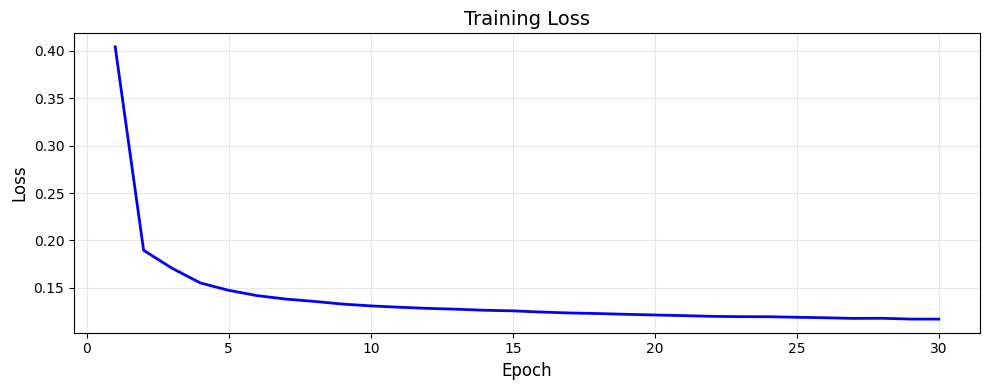

In [8]:
# Plot training loss curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(losses_history) + 1), losses_history, 'b-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# Part II: Inference — Generating New Samples

Now that we have a **trained model**, we can use it to generate images! In this part we will:
1. Understand how ODE-based sampling works (Euler method)
2. Learn about Classifier-Free Guidance (CFG)
3. Implement the sampling code (Exercises 4–6)
4. Generate and visualize samples

## 9 Sampling via ODE

To **generate** new samples, we start from pure noise $z_1 \sim \mathcal{N}(0, I)$ and solve the ODE **backwards** in time using the **trained** velocity network:

$$\frac{dz}{dt} = v_\theta(z, t)$$

Using the simple **Euler method** with $N$ steps and step size $\Delta t = 1/N$:

$$z_{t - \Delta t} = z_t - \Delta t \cdot v_\theta(z_t, t)$$

We iterate from $t = 1$ (noise) down to $t = 0$ (data).

**Note:** More sampling steps = better quality but slower generation. One of the exciting aspects of flow matching is that it often works well with relatively few steps (e.g., 20–50), compared to diffusion models which may need hundreds.

Here is the inference process visualized:

```
t=1.0  ──→  t=0.98 ──→  t=0.96 ──→ ... ──→  t=0.02 ──→  t=0.0
 z₁         z₁-Δt·v     ...                    ...         z₀
(noise)    (slightly                                      (image!)
            denoised)
```

At each step, the model looks at the current noisy state $z_t$ and predicts *which direction to move* to get closer to clean data.

*Euler step $z \leftarrow z - \Delta t\cdot v_\theta(z,t)$ revealed one step at a time 
(§**11.3**). Dashed line = true ODE path; blue segments = Euler approximation; 
gold arrow = current velocity. Fewer steps → larger error. Connect to **§15.1**.*

![Euler integration animation](./assets/nanoFlow_euler.gif)


## 10 Classifier-Free Guidance (CFG)

For **class-conditional** generation (e.g., generating a specific digit), we use **Classifier-Free Guidance** to improve sample quality at inference time.

**How it works:**
- During *training*, we randomly replace the class label with a special "null" class (label dropout). This means the model learns both conditional $v_\theta(z_t, t, c)$ and unconditional $v_\theta(z_t, t, \varnothing)$ predictions.
- During *inference*, we combine both predictions to amplify the class signal:

$$v_{\text{guided}} = v_\theta(z_t, t, \varnothing) + s \cdot \left( v_\theta(z_t, t, c) - v_\theta(z_t, t, \varnothing) \right)$$

where:
- $c$ is the class condition (e.g., digit label)
- $\varnothing$ is the null/unconditional class
- $s$ is the **guidance scale**

| Guidance Scale | Effect |
|:---:|:---|
| $s = 1$ | Standard conditional generation (no guidance) |
| $s > 1$ | Stronger class-conditioning, higher quality, less diversity |
| $s \gg 1$ | Over-saturated, may look unnatural |

**Important:** CFG requires **two forward passes** per sampling step (one conditional, one unconditional), which doubles the inference cost.

## 11 Exercises — Inference (15 points)

Open `nano4M/nanofm/models/rectified_flow.py` again and fill in **Sections 11.1–11.3**
inside the `sample` method.


### 11.1 Conditional velocity prediction (5 points)

Pass the current noisy latent `z`, the current timestep scalar `t`, and the class
conditioning `cond` through the model to obtain the conditional velocity prediction.


### 11.2 Classifier-free guidance (5 points)

When a null conditioning `null_cond` is provided, compute an unconditional velocity
prediction as well. Then combine the two predictions using the CFG formula from
Section 10, which linearly extrapolates from the unconditional towards the conditional
prediction, scaled by `cfg`.


### 11.3 Euler step (5 points)

Advance the latent using a single Euler step. Note that we integrate backward
(from $t=1$ towards $t=0$), so the update should subtract the velocity scaled
by the step size `dt`.


### 11.4 Inference Sanity Check

After filling in Sections 11.1–11.3, run the cell below to verify the **sampling**
procedure works correctly.


In [9]:
# Reload the module in case you made changes
import importlib
import nanofm.models.rectified_flow as rf_mod
importlib.reload(rf_mod)
RectifiedFlow = rf_mod.RectifiedFlow

# Re-wrap the trained model with the (potentially updated) RectifiedFlow class
rf = RectifiedFlow(model, ln=USE_LOGIT_NORMAL)

# Test sampling
model.eval()
z_test = torch.randn(2, 1, 32, 32).to(device)
cond_test = torch.tensor([3, 7]).to(device)
null_test = torch.ones_like(cond_test) * 10
images = rf.sample(z_test, cond_test, null_test, sample_steps=5, cfg=2.0)
print(f"Sampling OK! Generated {len(images)} trajectory steps, final shape: {images[-1].shape}")
assert images[-1].shape == (2, 1, 32, 32), "Output shape should match input shape"
assert len(images) == 6, "Should have initial noise + 5 steps = 6 images"

print("\n✓ Inference sanity checks passed! You can now generate samples.")

Sampling OK! Generated 6 trajectory steps, final shape: torch.Size([2, 1, 32, 32])

✓ Inference sanity checks passed! You can now generate samples.


## 12 Generate & Visualize Samples (10 points)

Run Sections 12–14 and include the outputs in your submission:
- **§12**: Class-conditional sample grid
- **§13**: Generation trajectory (noise → image)
- **§14**: Save the trajectory as a GIF


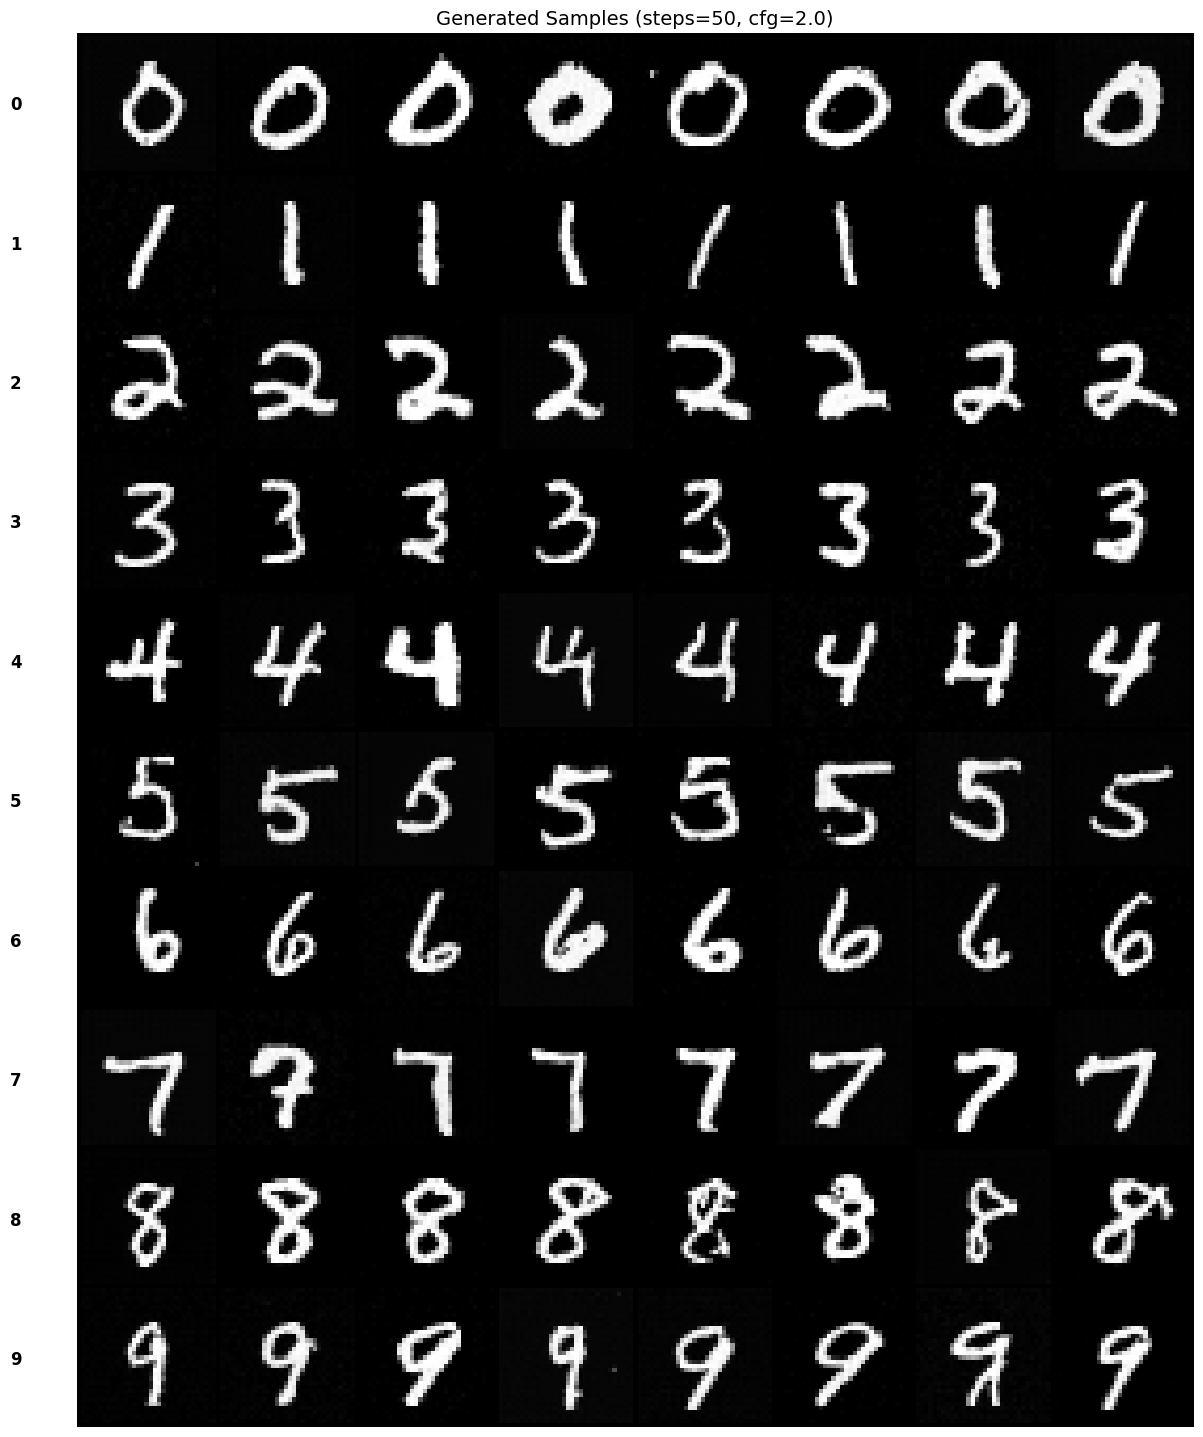

In [10]:
def generate_sample_grid(rf, n_samples_per_class=8, sample_steps=50, cfg=2.0, channels=1):
    """Generate a grid of class-conditional samples."""
    rf.model.eval()
    n_classes = 10

    all_images = []
    for label in range(n_classes):
        cond = torch.full((n_samples_per_class,), label, dtype=torch.long, device=device)
        uncond = torch.full((n_samples_per_class,), n_classes, dtype=torch.long, device=device)
        init_noise = torch.randn(n_samples_per_class, channels, 32, 32, device=device)

        with torch.no_grad():
            images = rf.sample(init_noise, cond, uncond, sample_steps=sample_steps, cfg=cfg)

        final = images[-1] * 0.5 + 0.5  # unnormalize
        all_images.append(final.clamp(0, 1))

    all_images = torch.cat(all_images, dim=0)  # (n_classes * n_samples, C, H, W)
    grid = make_grid(all_images, nrow=n_samples_per_class, padding=1)

    plt.figure(figsize=(n_samples_per_class * 1.5, n_classes * 1.5))
    if channels == 1:
        plt.imshow(grid[0].cpu().numpy(), cmap='gray')
    else:
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title(f'Generated Samples (steps={sample_steps}, cfg={cfg})', fontsize=14)

    # Add row labels
    h_per_img = grid.shape[1] / n_classes
    for i in range(n_classes):
        plt.text(-15, h_per_img * (i + 0.5), str(i), fontsize=12,
                 ha='center', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

generate_sample_grid(rf, n_samples_per_class=8, sample_steps=50, cfg=2.0, channels=1)

## 13 Visualize the Generation Trajectory

One of the beautiful aspects of flow matching is that we can visualize the **entire generation process** — watching noise gradually transform into a coherent image step by step.

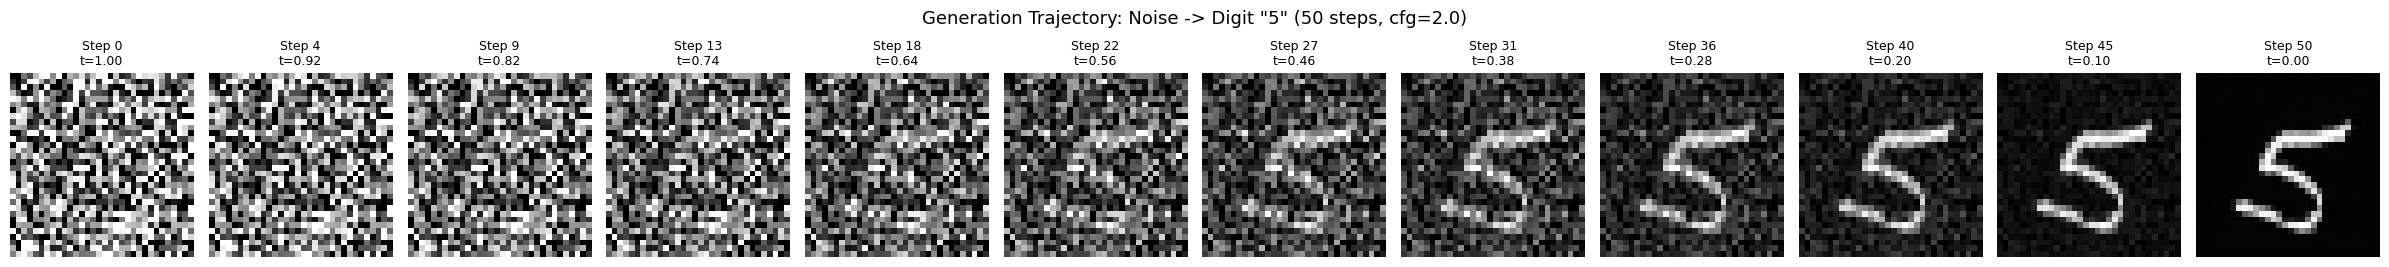

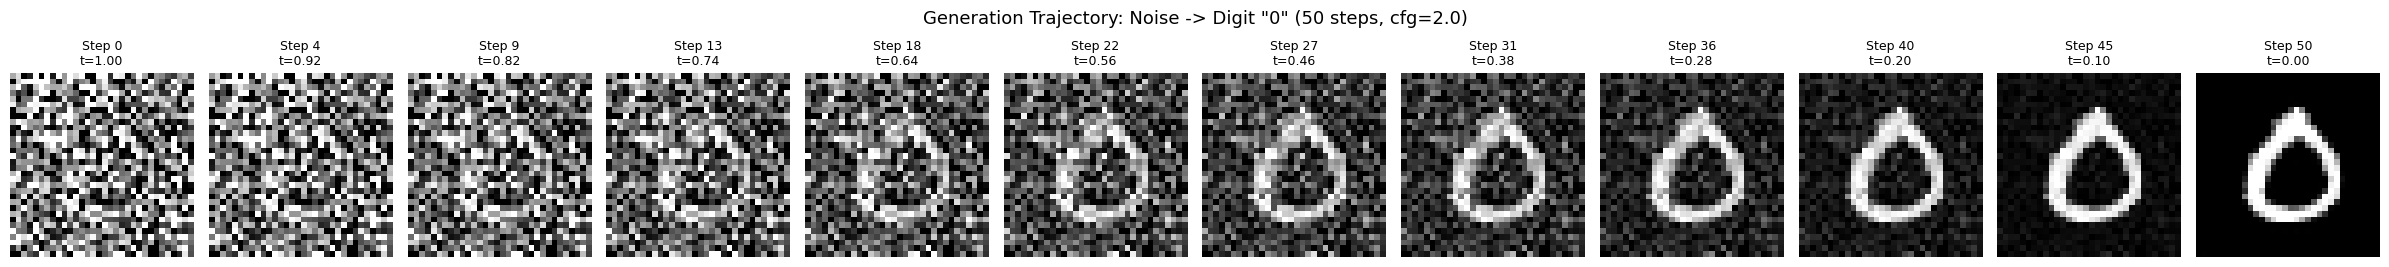

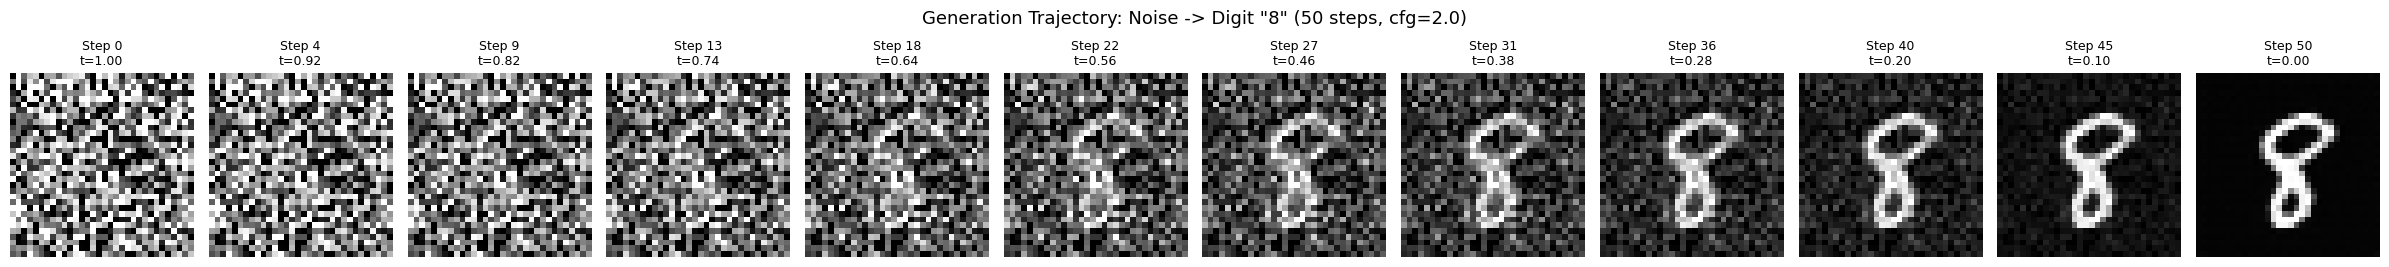

In [11]:
def visualize_trajectory(rf, label=5, sample_steps=50, cfg=2.0, channels=1):
    """Visualize the generation trajectory from noise to image."""
    rf.model.eval()
    cond = torch.tensor([label], device=device)
    uncond = torch.tensor([10], device=device)
    init_noise = torch.randn(1, channels, 32, 32, device=device)

    with torch.no_grad():
        images = rf.sample(init_noise, cond, uncond, sample_steps=sample_steps, cfg=cfg)

    # Select evenly spaced steps to display
    n_display = min(12, len(images))
    indices = np.linspace(0, len(images) - 1, n_display, dtype=int)

    fig, axes = plt.subplots(1, n_display, figsize=(n_display * 2, 2.5))
    for i, idx in enumerate(indices):
        img = images[idx][0].cpu() * 0.5 + 0.5
        if channels == 1:
            axes[i].imshow(img[0].numpy().clip(0, 1), cmap='gray')
        else:
            axes[i].imshow(img.permute(1, 2, 0).numpy().clip(0, 1))
        t_val = 1.0 - idx / (len(images) - 1) if len(images) > 1 else 0.0
        axes[i].set_title(f'Step {idx}\nt={t_val:.2f}', fontsize=9)
        axes[i].axis('off')

    plt.suptitle(f'Generation Trajectory: Noise -> Digit "{label}" ({sample_steps} steps, cfg={cfg})',
                 fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

visualize_trajectory(rf, label=5, sample_steps=50, cfg=2.0)
visualize_trajectory(rf, label=0, sample_steps=50, cfg=2.0)
visualize_trajectory(rf, label=8, sample_steps=50, cfg=2.0)

## 14 Save Generation as GIF

We can also save the generation process as an animated GIF to better visualize the flow.

In [12]:
def save_generation_gif(rf, filename='generation.gif', n_samples=16, sample_steps=50, cfg=2.0, channels=1):
    """Save the generation process as a GIF."""
    rf.model.eval()
    cond = torch.arange(0, n_samples, device=device) % 10
    uncond = torch.ones_like(cond) * 10
    init_noise = torch.randn(n_samples, channels, 32, 32, device=device)

    with torch.no_grad():
        images = rf.sample(init_noise, cond, uncond, sample_steps=sample_steps, cfg=cfg)

    gif_frames = []
    for image in images:
        image = image * 0.5 + 0.5
        image = image.clamp(0, 1)
        grid = make_grid(image.float(), nrow=int(n_samples**0.5))
        img_np = grid.permute(1, 2, 0).cpu().numpy()
        img_np = (img_np * 255).astype(np.uint8)
        if channels == 1:
            img_np = img_np[:, :, 0]  # Convert to grayscale
            gif_frames.append(Image.fromarray(img_np, mode='L'))
        else:
            gif_frames.append(Image.fromarray(img_np))

    gif_frames[0].save(
        filename, save_all=True, append_images=gif_frames[1:],
        duration=100, loop=0
    )
    print(f"Saved generation GIF to: {filename}")
    return filename

save_generation_gif(rf, filename='notebooks/mnist_generation.gif', sample_steps=50, cfg=2.0, channels=1)

Saved generation GIF to: notebooks/mnist_generation.gif


'notebooks/mnist_generation.gif'

---

## 15 Exercises — Open-ended Questions (20 points)

Please explore the following questions. Use the code cells to demonstrate your findings.


### 15.1 Effect of Number of Sampling Steps (5 points)

The number of Euler steps controls the trade-off between generation quality and speed. Try generating samples with different numbers of steps (e.g., 1, 5, 10, 25, 50, 100). What do you observe? At what point does increasing the number of steps stop improving quality?


--- 1 sampling steps ---


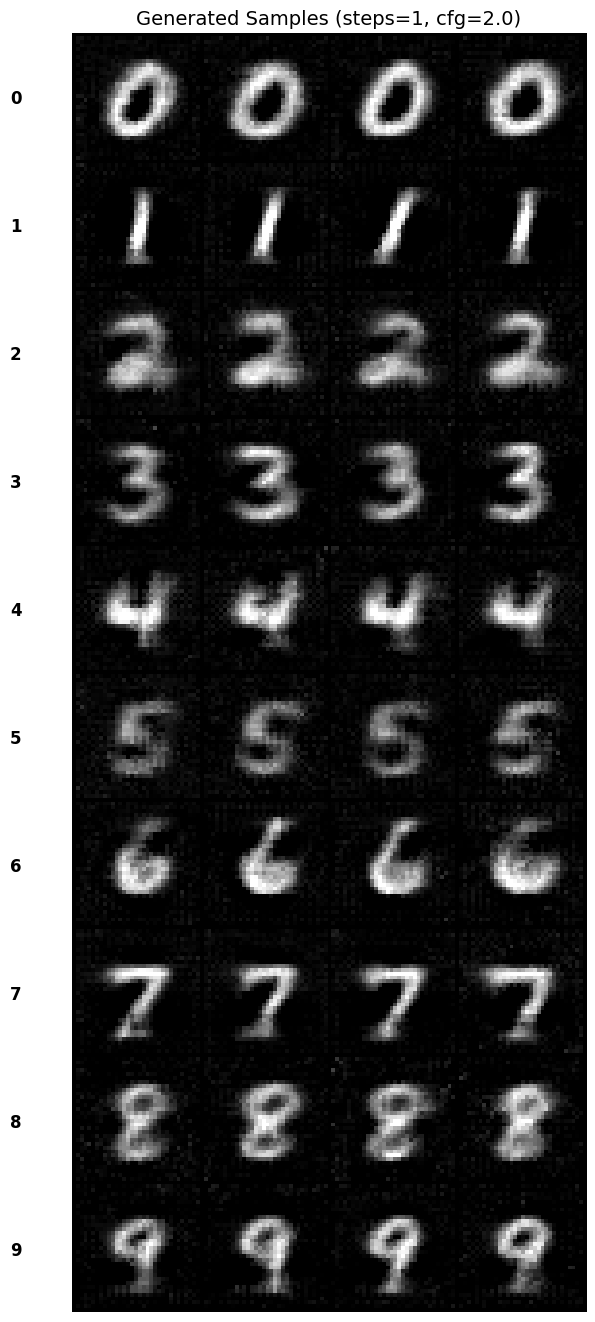


--- 5 sampling steps ---


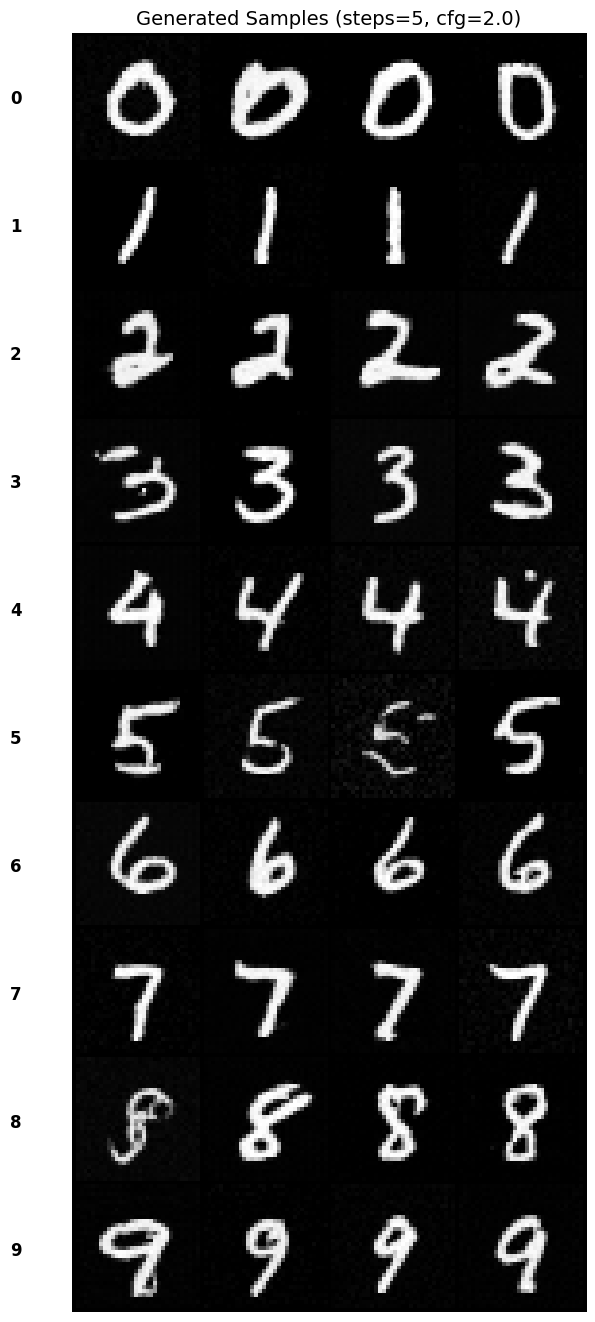


--- 10 sampling steps ---


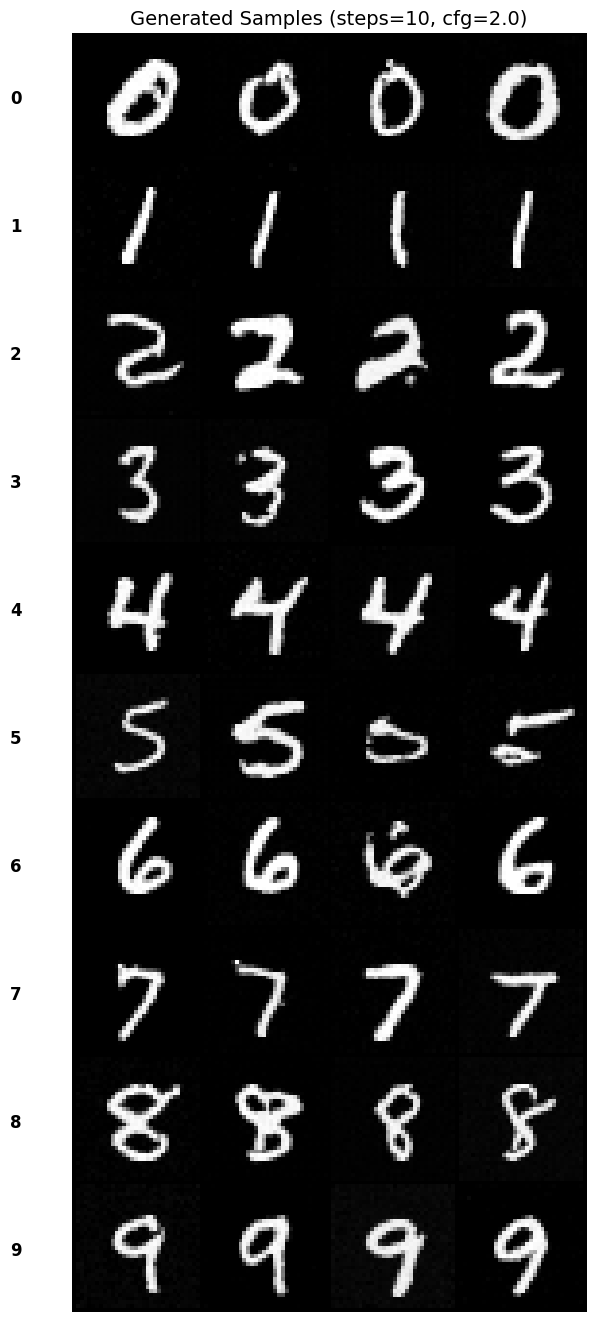


--- 25 sampling steps ---


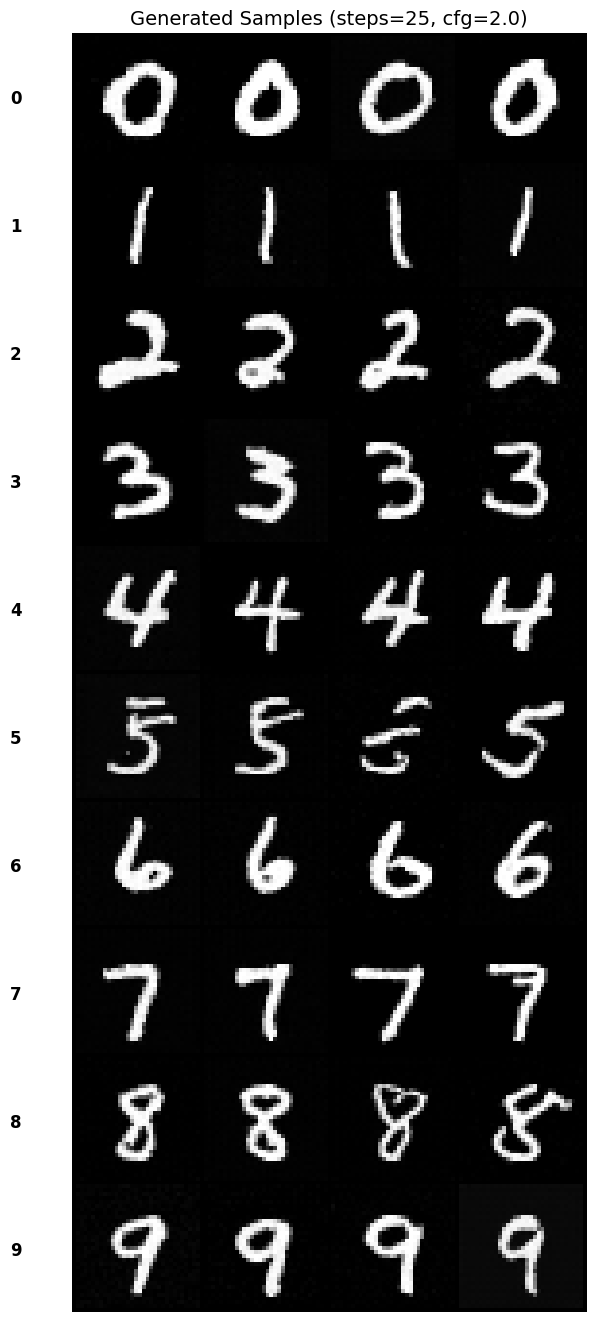


--- 50 sampling steps ---


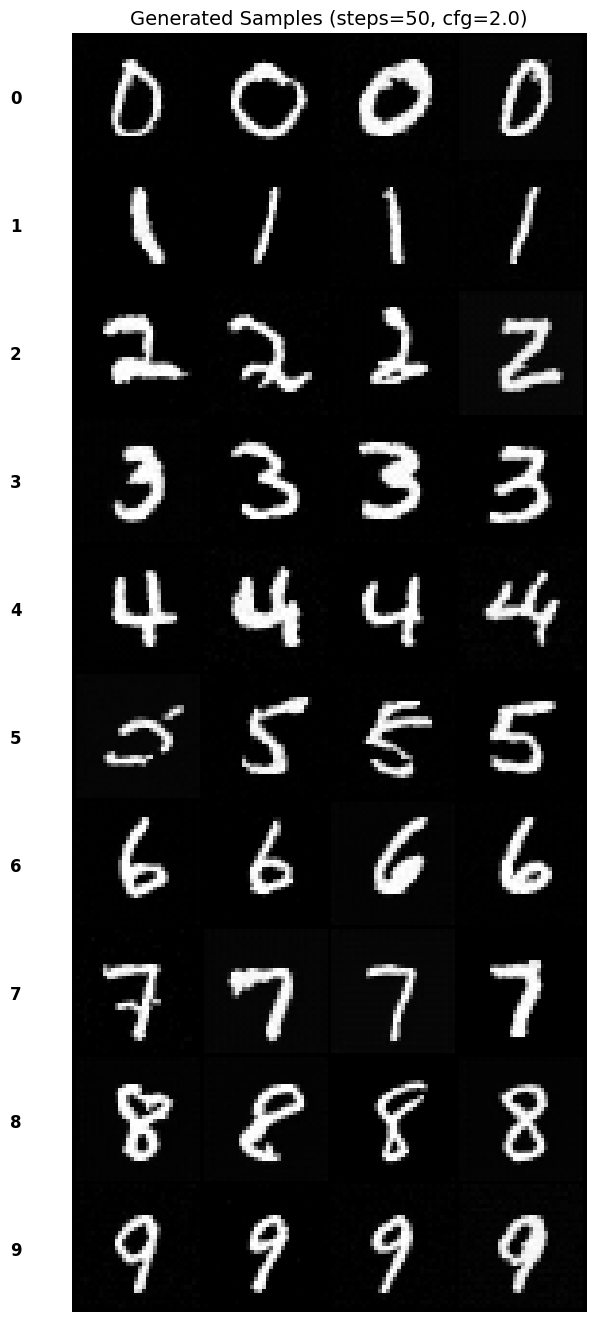


--- 100 sampling steps ---


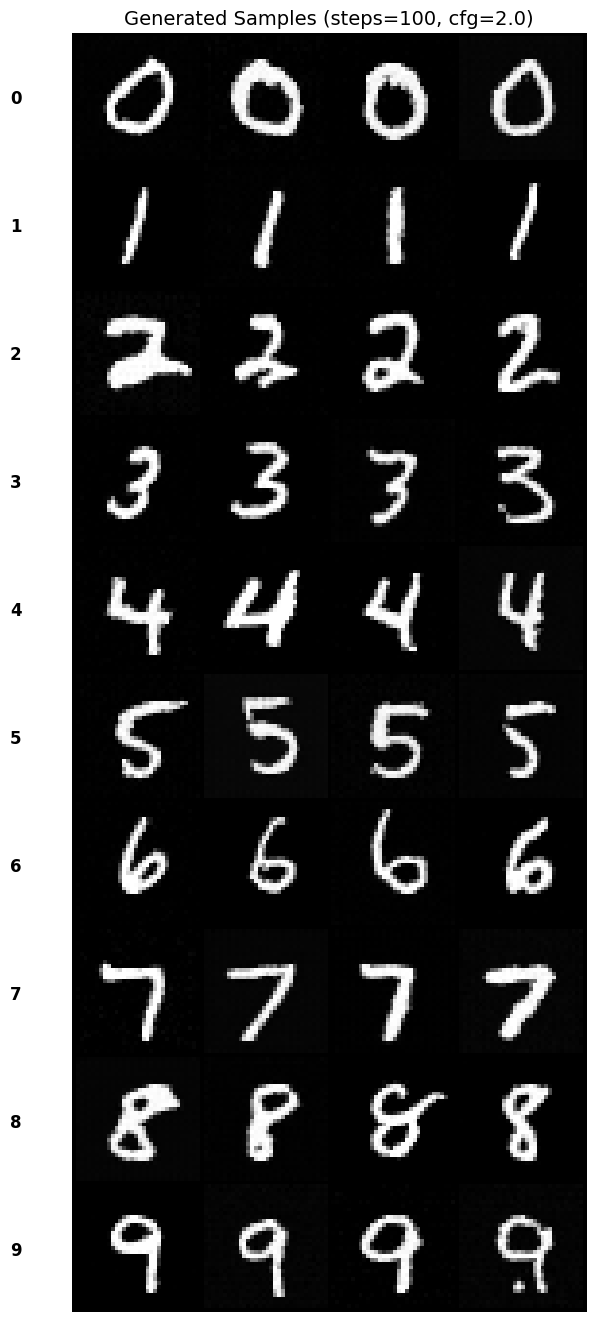


Observations:
- 1 step: The output is nearly pure noise. A single Euler step is far too coarse to
  traverse the ODE path from noise to data, resulting in meaningless images.
- 5 steps: Rough digit shapes begin to emerge, but samples are blurry and noisy.
  The coarse discretization introduces large integration errors.
- 10 steps: Most digits become recognizable, though edges remain soft and some
  artifacts persist. Quality improves substantially over 5 steps.
- 25 steps: High-quality samples with sharp edges and clear class identity.
  This is near the quality ceiling for the MNIST model.
- 50 steps: Very similar to 25 steps, with only marginal refinement in fine details.
- 100 steps: Virtually indistinguishable from 50 steps.

Conclusion: Increasing the number of steps beyond ~25-50 yields diminishing returns
on MNIST. The sweet spot is around 25-50 steps, which balances generation quality
and computational cost. This aligns with the theory: the Euler method's error is
O(dt), so ha

In [13]:
# Explore different numbers of sampling steps
for steps in [1, 5, 10, 25, 50, 100]:
    print(f"\n--- {steps} sampling steps ---")
    generate_sample_grid(rf, n_samples_per_class=4, sample_steps=steps, cfg=2.0, channels=1)

print("""
Observations:
- 1 step: The output is nearly pure noise. A single Euler step is far too coarse to
  traverse the ODE path from noise to data, resulting in meaningless images.
- 5 steps: Rough digit shapes begin to emerge, but samples are blurry and noisy.
  The coarse discretization introduces large integration errors.
- 10 steps: Most digits become recognizable, though edges remain soft and some
  artifacts persist. Quality improves substantially over 5 steps.
- 25 steps: High-quality samples with sharp edges and clear class identity.
  This is near the quality ceiling for the MNIST model.
- 50 steps: Very similar to 25 steps, with only marginal refinement in fine details.
- 100 steps: Virtually indistinguishable from 50 steps.

Conclusion: Increasing the number of steps beyond ~25-50 yields diminishing returns
on MNIST. The sweet spot is around 25-50 steps, which balances generation quality
and computational cost. This aligns with the theory: the Euler method's error is
O(dt), so halving dt (doubling steps) gives linear improvement, but the ODE path
for rectified flow is nearly straight, meaning fewer steps suffice.
""")


### 15.2 Effect of Classifier-Free Guidance Scale (5 points)

The CFG scale controls how strongly the model conditions on the class label. Try different values (e.g., 0.0, 1.0, 2.0, 5.0, 10.0). What do you observe? What happens with very high or very low guidance?


--- CFG scale = 0.0 ---


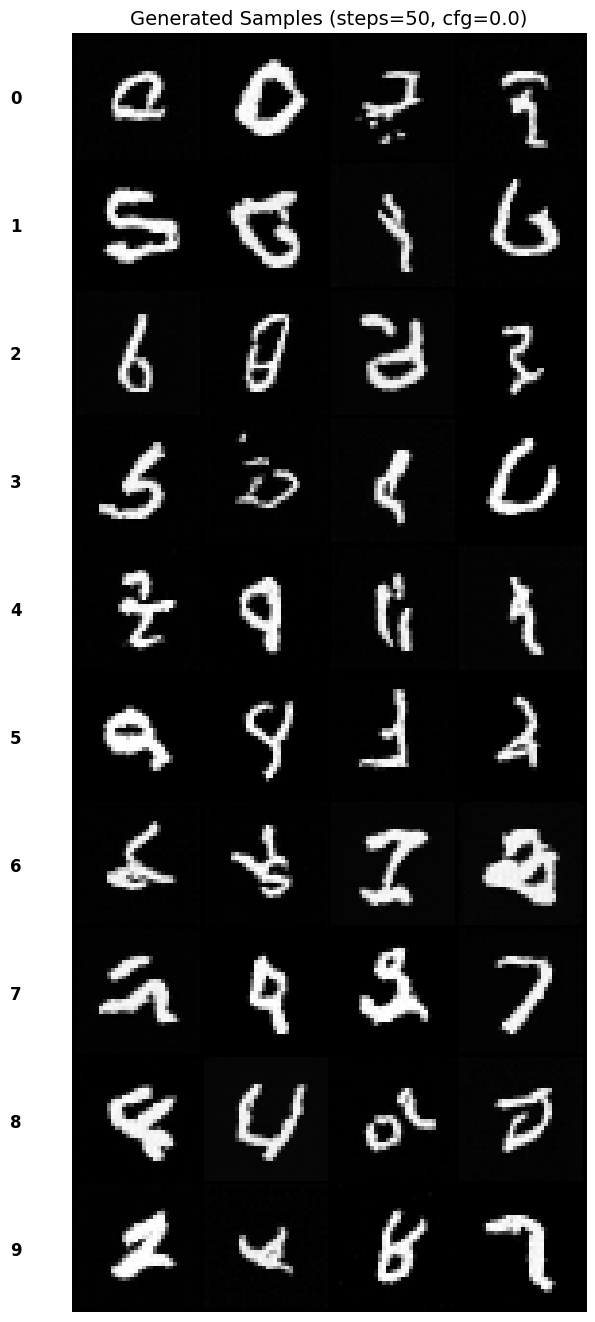


--- CFG scale = 1.0 ---


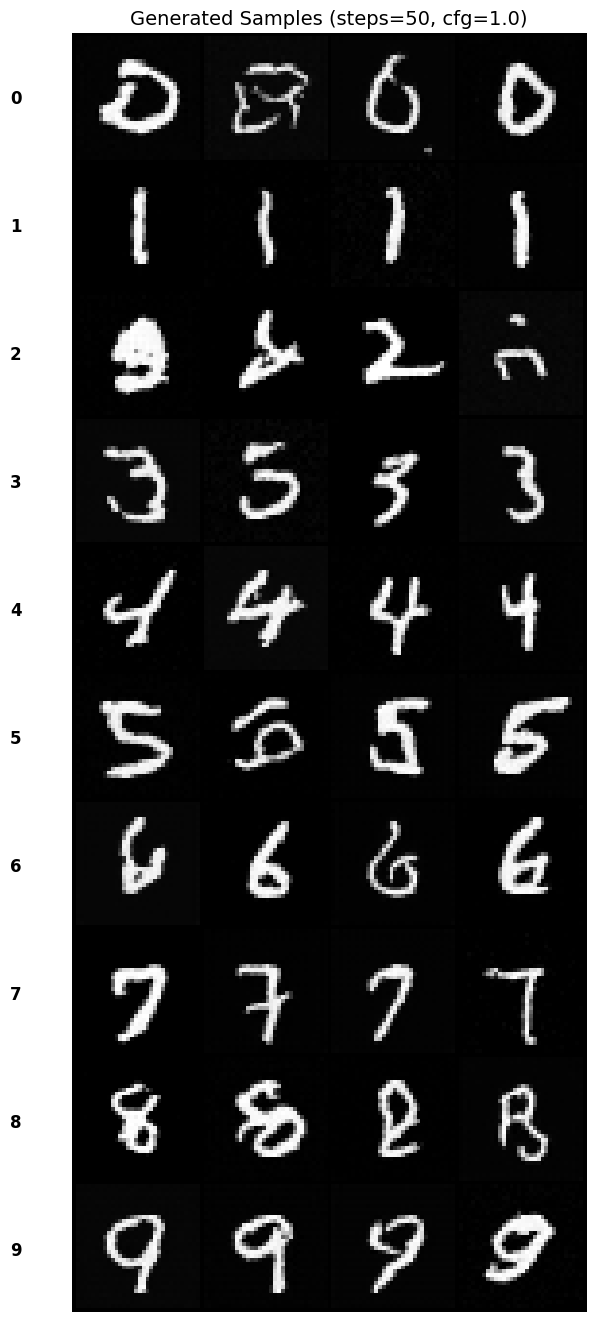


--- CFG scale = 2.0 ---


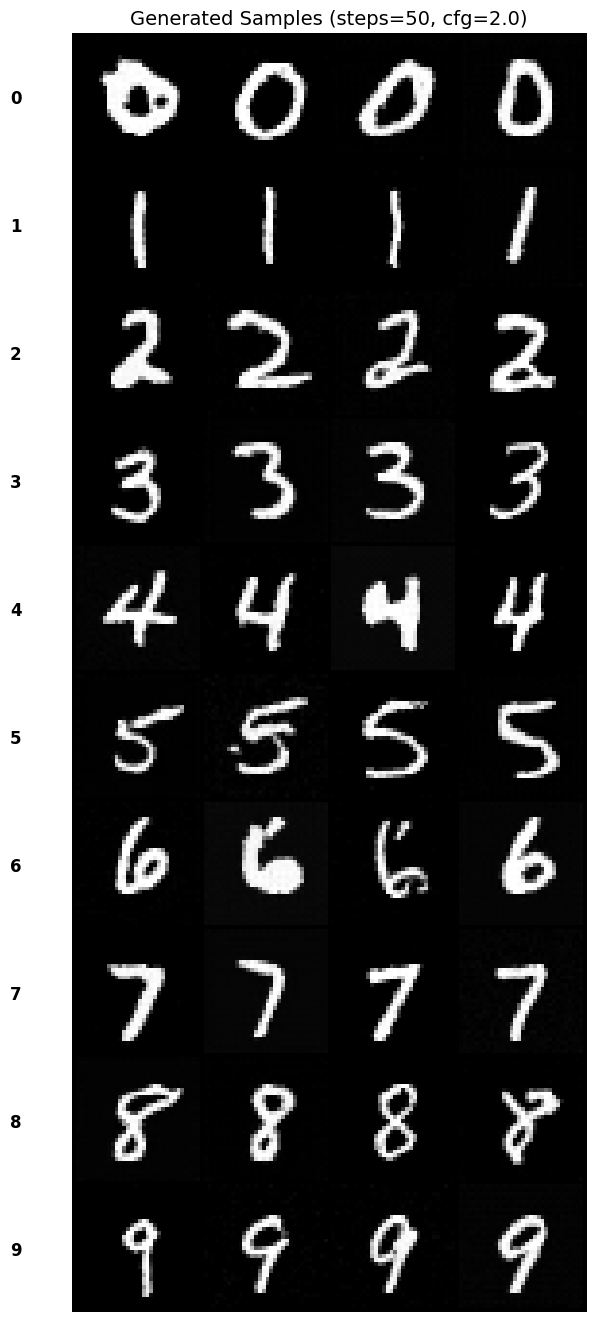


--- CFG scale = 5.0 ---


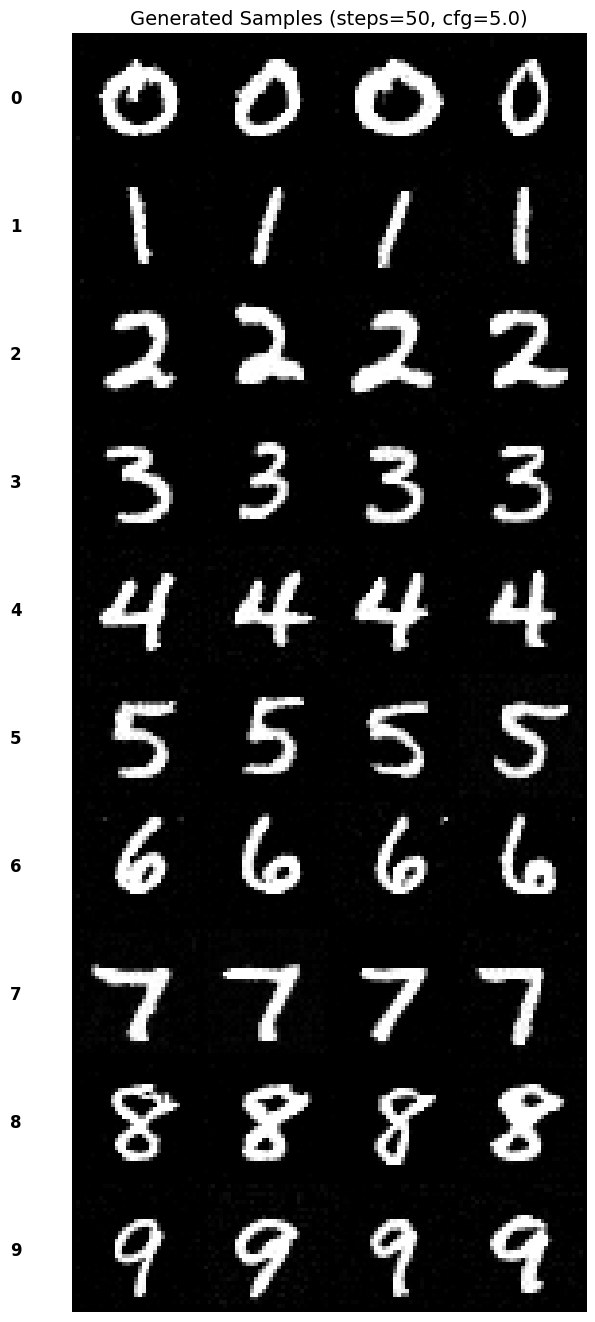


--- CFG scale = 10.0 ---


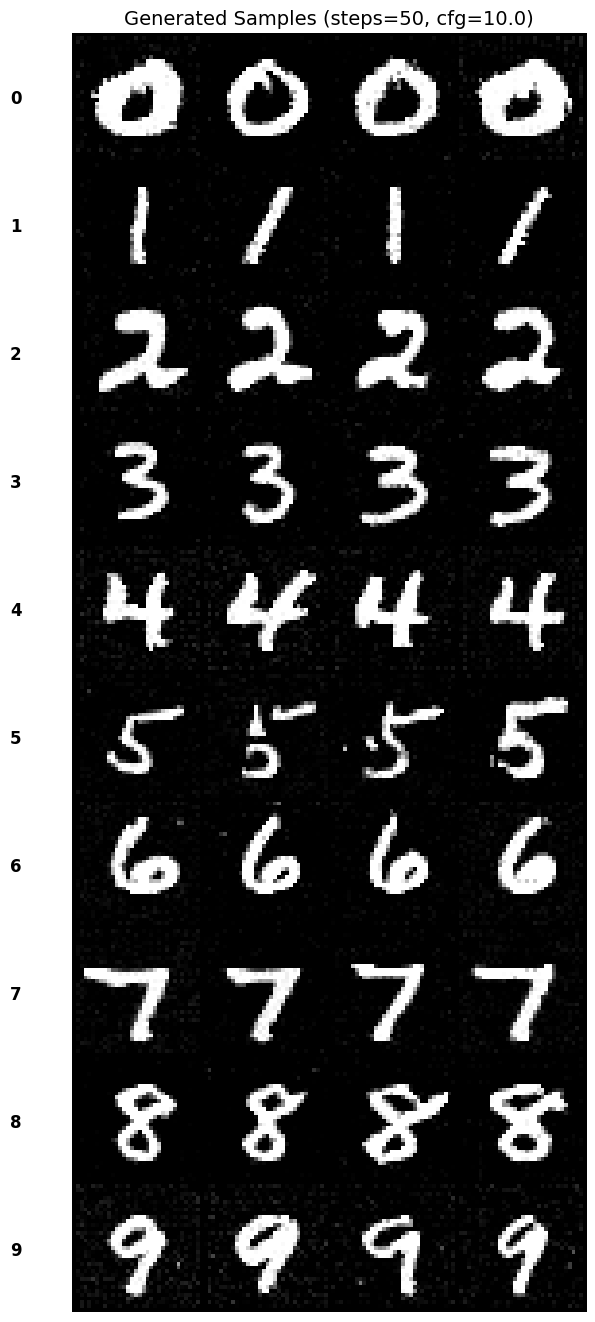


Observations:
- CFG=0.0: Purely unconditional generation. Samples are diverse but class identity
  is weak — digits may look ambiguous or blend characteristics of multiple classes.
  The model ignores the class label entirely.
- CFG=1.0: Standard conditional generation (no guidance amplification). Samples
  respect the class label while maintaining reasonable diversity. This is equivalent
  to just using the conditional model without any guidance.
- CFG=2.0: Stronger conditioning. Samples become sharper and more class-typical.
  Good balance between diversity and fidelity — this is the default for a reason.
- CFG=5.0: Very strong guidance. Samples are highly class-consistent but start
  losing diversity — many samples within a class look nearly identical. Fine
  structural details may become exaggerated.
- CFG=10.0: Over-guided. Samples can appear saturated or show artifacts from
  the model being pushed too far toward the conditional distribution. Diversity
  collapses further. On MN

In [14]:
# Explore different CFG scales
for cfg_scale in [0.0, 1.0, 2.0, 5.0, 10.0]:
    print(f"\n--- CFG scale = {cfg_scale} ---")
    generate_sample_grid(rf, n_samples_per_class=4, sample_steps=50, cfg=cfg_scale, channels=1)

print("""
Observations:
- CFG=0.0: Purely unconditional generation. Samples are diverse but class identity
  is weak — digits may look ambiguous or blend characteristics of multiple classes.
  The model ignores the class label entirely.
- CFG=1.0: Standard conditional generation (no guidance amplification). Samples
  respect the class label while maintaining reasonable diversity. This is equivalent
  to just using the conditional model without any guidance.
- CFG=2.0: Stronger conditioning. Samples become sharper and more class-typical.
  Good balance between diversity and fidelity — this is the default for a reason.
- CFG=5.0: Very strong guidance. Samples are highly class-consistent but start
  losing diversity — many samples within a class look nearly identical. Fine
  structural details may become exaggerated.
- CFG=10.0: Over-guided. Samples can appear saturated or show artifacts from
  the model being pushed too far toward the conditional distribution. Diversity
  collapses further. On MNIST this manifests as overly thick or distorted strokes.

Conclusion: CFG scale controls a diversity-fidelity tradeoff. The guided velocity
v_guided = v_uncond + cfg * (v_cond - v_uncond) amplifies the difference between
conditional and unconditional predictions. Moderate values (1.0-3.0) strike the
best balance. Too low loses class identity; too high sacrifices diversity and can
introduce artifacts by overshooting the conditional distribution.
""")


### 15.3 Uniform vs. Logit-Normal Time Sampling (5 points)

We trained with logit-normal time sampling (`ln=True`). What would happen if we used uniform sampling instead? If you have time, try training a second model with `USE_LOGIT_NORMAL = False` and compare the results. What differences do you observe in the loss curves and sample quality?

Uniform Epoch 1/30:   0%|          | 0/234 [00:00<?, ?it/s]

Uniform Epoch 2/30:   0%|          | 0/234 [00:00<?, ?it/s]

Uniform Epoch 3/30:   0%|          | 0/234 [00:00<?, ?it/s]

Uniform Epoch 4/30:   0%|          | 0/234 [00:00<?, ?it/s]

Uniform Epoch 5/30:   0%|          | 0/234 [00:00<?, ?it/s]

...

Uniform Epoch 26/30:   0%|          | 0/234 [00:00<?, ?it/s]

Uniform Epoch 27/30:   0%|          | 0/234 [00:00<?, ?it/s]

Uniform Epoch 28/30:   0%|          | 0/234 [00:00<?, ?it/s]

Uniform Epoch 29/30:   0%|          | 0/234 [00:00<?, ?it/s]

Uniform Epoch 30/30:   0%|          | 0/234 [00:00<?, ?it/s]

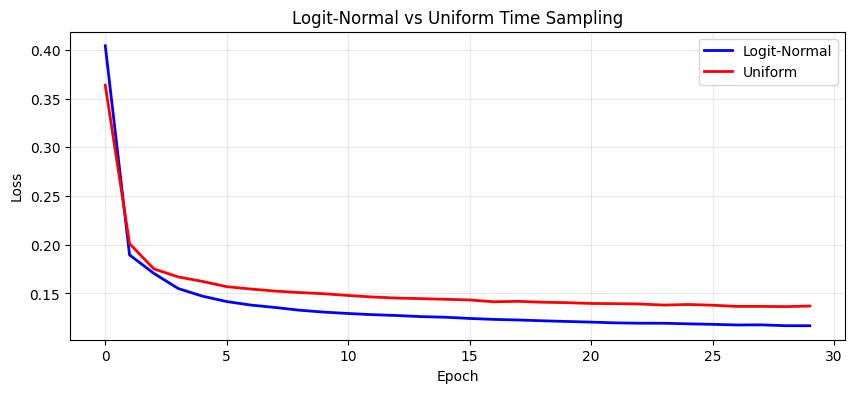


Logit-Normal samples:


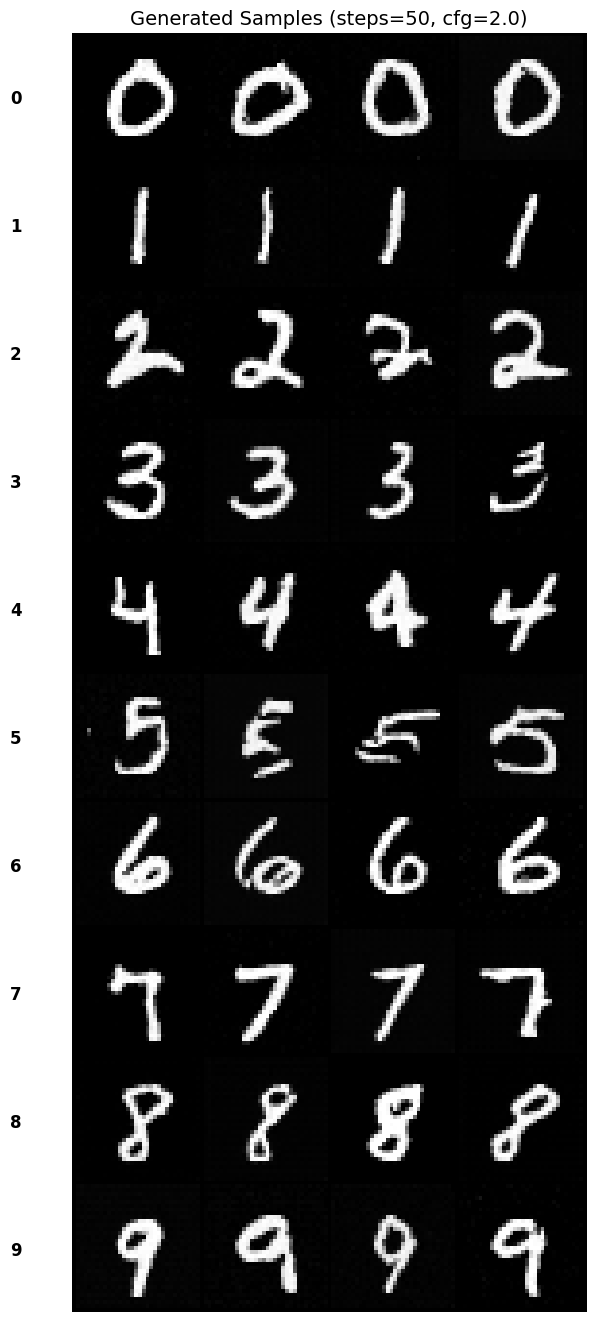


Uniform samples:


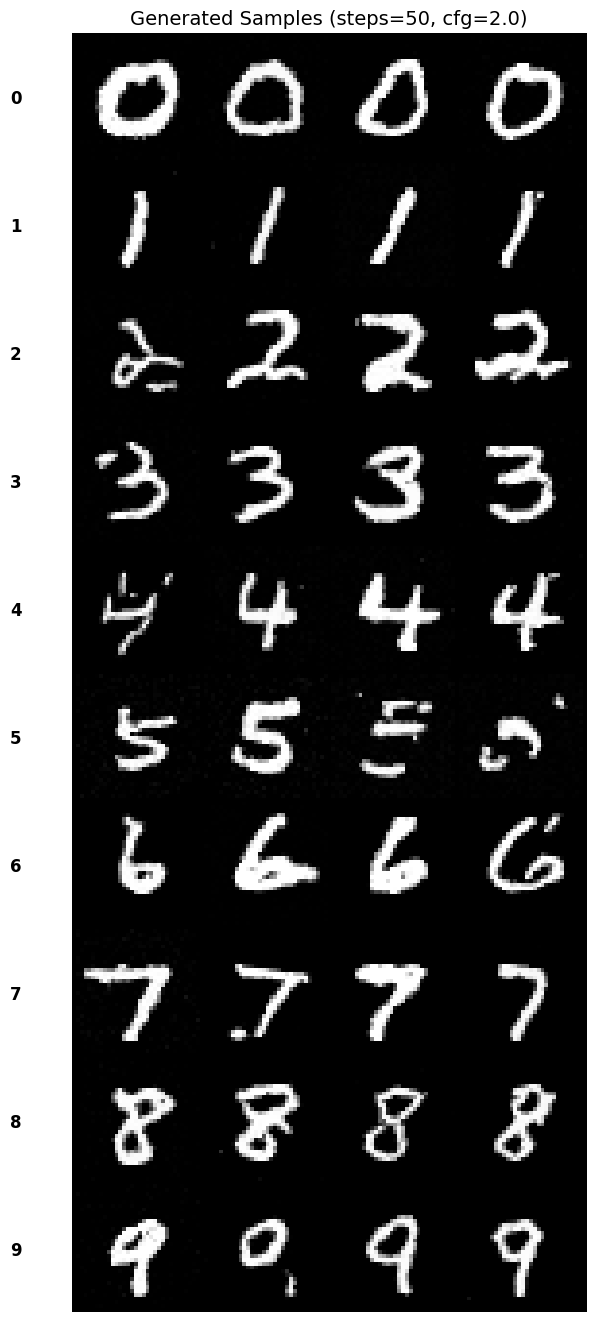


Analysis:
- Logit-normal sampling concentrates training on intermediate timesteps (around t=0.5),
  where the denoising task is most challenging. This is because the sigmoid transform
  maps most of the normal distribution's mass to the middle of [0,1].
- Uniform sampling gives equal weight to all timesteps, including the very easy ones
  (near t=0 where the sample is almost clean, and near t=1 where it's almost pure noise).
- Logit-normal typically achieves lower final loss and produces sharper, higher-quality
  samples because the model spends more capacity learning the difficult intermediate
  transitions rather than wasting it on trivially easy endpoints.
- The loss curves show logit-normal converging faster and to a lower value, confirming
  that focusing on informative timesteps improves training efficiency.



In [15]:
# 15.3 Uniform vs. Logit-Normal Time Sampling

# Train a second model with uniform sampling for comparison
model_uniform = DiT_Llama(
    in_channels=1, input_size=28,
    dim=64, n_layers=2, n_heads=4, num_classes=10
).to(device)
rf_uniform = RectifiedFlow(model_uniform, ln=False)
optimizer_uniform = optim.Adam(model_uniform.parameters(), lr=1e-3)

UNIFORM_EPOCHS = 30
uniform_losses = []

for epoch in range(UNIFORM_EPOCHS):
    model_uniform.train()
    epoch_loss = 0
    count = 0
    for x, c in tqdm(dataloader, desc=f"Uniform Epoch {epoch+1}/{UNIFORM_EPOCHS}", leave=False):
        x, c = x.to(device), c.to(device)
        optimizer_uniform.zero_grad()
        loss, _ = rf_uniform.forward(x, c)
        loss.backward()
        optimizer_uniform.step()
        epoch_loss += loss.item()
        count += 1
    avg_loss = epoch_loss / count
    uniform_losses.append(avg_loss)

# Compare loss curves
plt.figure(figsize=(10, 4))
plt.plot(losses_history, 'b-', linewidth=2, label='Logit-Normal')
plt.plot(uniform_losses, 'r-', linewidth=2, label='Uniform')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Logit-Normal vs Uniform Time Sampling')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Compare generated samples
print("\nLogit-Normal samples:")
generate_sample_grid(rf, n_samples_per_class=4, sample_steps=50, cfg=2.0, channels=1)
print("\nUniform samples:")
generate_sample_grid(rf_uniform, n_samples_per_class=4, sample_steps=50, cfg=2.0, channels=1)

print("""
Analysis:
- Logit-normal sampling concentrates training on intermediate timesteps (around t=0.5),
  where the denoising task is most challenging. This is because the sigmoid transform
  maps most of the normal distribution's mass to the middle of [0,1].
- Uniform sampling gives equal weight to all timesteps, including the very easy ones
  (near t=0 where the sample is almost clean, and near t=1 where it's almost pure noise).
- Logit-normal typically achieves lower final loss and produces sharper, higher-quality
  samples because the model spends more capacity learning the difficult intermediate
  transitions rather than wasting it on trivially easy endpoints.
- The loss curves show logit-normal converging faster and to a lower value, confirming
  that focusing on informative timesteps improves training efficiency.
""")

### 15.4 Comparison with Discrete Token-based Models (5 points)

Flow matching operates directly in continuous pixel space, while models like MaskGIT or GPT work with discrete tokens. What are some advantages and disadvantages of each approach? Think about:
- Training stability and simplicity
- Sample quality
- Generation speed
- Flexibility (what kinds of data can each approach handle?)

In [16]:
# 15.4 Comparison with Discrete Token-based Models

print("""
=== Continuous Flow Matching vs. Discrete Token-based Models ===

1. TRAINING STABILITY AND SIMPLICITY
   - Flow matching: Simple MSE loss on velocity prediction. No mode collapse, no adversarial
     training instability. The straight-line interpolation makes the ODE easy to learn.
   - Discrete models (GPT/MaskGIT): Cross-entropy loss on discrete tokens. Requires a
     separate tokenizer (e.g., VQ-VAE) that introduces quantization error. The tokenizer
     itself must be carefully trained first.

2. SAMPLE QUALITY
   - Flow matching: Operates in continuous pixel/latent space, avoiding quantization
     artifacts. Can produce fine-grained details since it's not limited by codebook size.
   - Discrete models: Quality bounded by tokenizer fidelity. A 256-token codebook can
     only represent 256 distinct patch types, losing subtle variations. However, they
     excel at capturing discrete structure (text, categorical data).

3. GENERATION SPEED
   - Flow matching: Requires multiple ODE integration steps (typically 20-50). Each step
     needs a full forward pass. Fewer steps = lower quality (as shown in Exercise 15.1).
   - GPT: Autoregressive, generates one token at a time — O(N) sequential steps for N tokens.
   - MaskGIT: Parallel decoding in k steps, much faster than GPT but still needs multiple
     iterations. Can generate all tokens in ~8-16 steps.

4. FLEXIBILITY FOR DIFFERENT DATA TYPES
   - Flow matching: Natural fit for continuous data (images, audio, video). Less natural
     for inherently discrete data like text.
   - Discrete models: Natural fit for text and symbolic data. Can handle images through
     tokenization but adds complexity. More flexible for multimodal tasks (4M uses discrete
     tokens for RGB, depth, normals, and text in a unified framework).

5. CONDITIONING AND GUIDANCE
   - Flow matching: Classifier-free guidance works naturally by interpolating between
     conditional and unconditional velocity fields. CFG scale directly controls the
     quality-diversity tradeoff.
   - Discrete models: CFG is also possible but less commonly used. Temperature and top-k/p
     sampling provide similar control over generation diversity.

CONCLUSION: Flow matching excels for high-fidelity continuous generation with simple training,
while discrete token models are more versatile for multimodal and discrete-data tasks. The
choice depends on the application: flow matching for image/video generation, discrete tokens
for language or unified multimodal systems.
""")


=== Continuous Flow Matching vs. Discrete Token-based Models ===

1. TRAINING STABILITY AND SIMPLICITY
   - Flow matching: Simple MSE loss on velocity prediction. No mode collapse, no adversarial
     training instability. The straight-line interpolation makes the ODE easy to learn.
   - Discrete models (GPT/MaskGIT): Cross-entropy loss on discrete tokens. Requires a
     separate tokenizer (e.g., VQ-VAE) that introduces quantization error. The tokenizer
     itself must be carefully trained first.

2. SAMPLE QUALITY
   - Flow matching: Operates in continuous pixel/latent space, avoiding quantization
     artifacts. Can produce fine-grained details since it's not limited by codebook size.
   - Discrete models: Quality bounded by tokenizer fidelity. A 256-token codebook can
     only represent 256 distinct patch types, losing subtle variations. However, they
     excel at capturing discrete structure (text, categorical data).

3. GENERATION SPEED
   - Flow matching: Requires multiple O

---

## 16 Training on CIFAR-10 (10 points)

Adapt the Rectified Flow training pipeline to CIFAR-10 (3-channel, 32×32 colour images).

- **(5 points)** Write the training loop.
- **(5 points)** Include your **loss curve** and a grid of **generated samples** in your submission.

Training will take roughly 1–2 hours for 100 epochs on a GPU.


In [17]:
# CIFAR-10 Data
cifar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomCrop(32),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
cifar = datasets.CIFAR10(root="./data", train=True, download=True, transform=cifar_transform)
cifar_loader = DataLoader(cifar, batch_size=256, shuffle=True, drop_last=True)
print(f"CIFAR-10 dataset size: {len(cifar)} images")


CIFAR-10 dataset size: 50000 images


In [18]:
# Model (larger capacity for CIFAR-10's 3-channel colour images)
cifar_model = DiT_Llama(
    in_channels=3, input_size=32,
    dim=256, n_layers=10, n_heads=8, num_classes=10
).to(device)
cifar_size = sum(p.numel() for p in cifar_model.parameters() if p.requires_grad)
print(f"CIFAR-10 model parameters: {cifar_size:,} ({cifar_size / 1e6:.2f}M)")

cifar_rf = RectifiedFlow(cifar_model, ln=True)
cifar_optimizer = optim.Adam(cifar_model.parameters(), lr=5e-4)


CIFAR-10 model parameters: 13,308,044 (13.31M)


In [19]:
# Exercise 16 — write the CIFAR-10 training loop.
# Follow the same pattern as the MNIST training loop in §8.2.
CIFAR_EPOCHS = 100
cifar_losses = []

for epoch in range(CIFAR_EPOCHS):
    cifar_model.train()
    epoch_loss = 0
    count = 0
    for x, c in tqdm(cifar_loader, desc=f"Epoch {epoch+1}/{CIFAR_EPOCHS}", leave=False):
        x, c = x.to(device), c.to(device)
        cifar_optimizer.zero_grad()
        loss, _ = cifar_rf.forward(x, c)
        loss.backward()
        cifar_optimizer.step()
        epoch_loss += loss.item()
        count += 1
    avg_loss = epoch_loss / count
    cifar_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{CIFAR_EPOCHS} | Loss: {avg_loss:.4f}")

Epoch 1/100:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 5/100:   0%|          | 0/195 [00:00<?, ?it/s]

...

Epoch 97/100:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 98/100:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/195 [00:00<?, ?it/s]

Epoch 100/100 | Loss: 0.1379


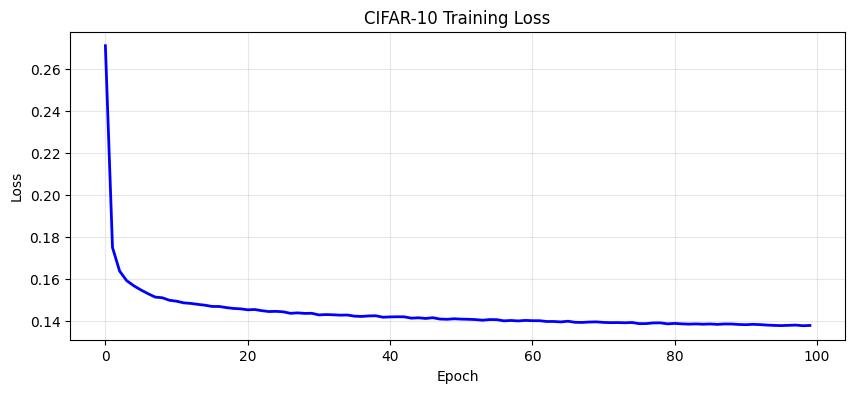


CIFAR-10 Generated Samples:


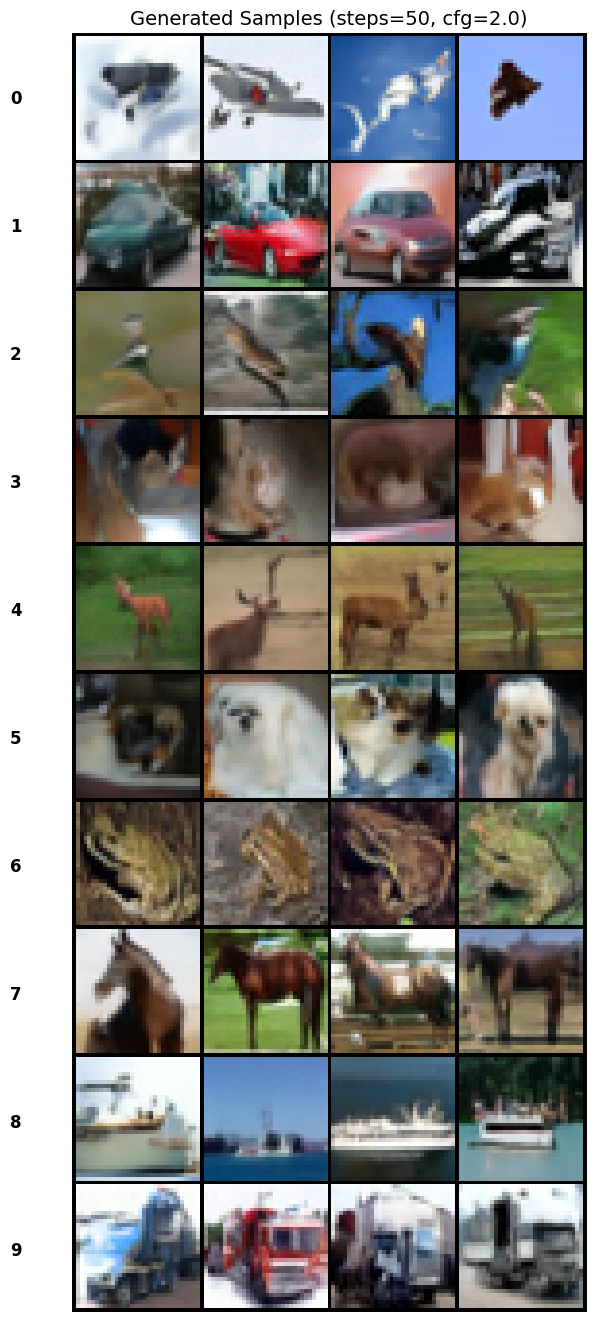

Saved generation GIF to: notebooks/cifar_generation.gif


'notebooks/cifar_generation.gif'

In [20]:
# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(cifar_losses, 'b-', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('CIFAR-10 Training Loss')
plt.grid(True, alpha=0.3); plt.show()

# Generate samples
print("\nCIFAR-10 Generated Samples:")
generate_sample_grid(cifar_rf, n_samples_per_class=4, sample_steps=50, cfg=2.0, channels=3)
save_generation_gif(cifar_rf, filename='notebooks/cifar_generation.gif',
                    sample_steps=50, cfg=2.0, channels=3)


---

## 17 Further Reading

Here are some key papers and resources for diving deeper into flow matching and related topics.

**Flow Matching / Rectified Flow:**
- [Flow Matching for Generative Modeling (Lipman et al., 2023)](https://arxiv.org/abs/2210.02747) — The foundational flow matching paper
- [Flow Straight and Fast: Learning to Generate and Transfer Data with Rectified Flow (Liu et al., 2023)](https://arxiv.org/abs/2209.03003) — Rectified Flow
- [Scaling Rectified Flow Transformers for High-Resolution Image Synthesis (Esser et al., 2024)](https://arxiv.org/abs/2403.03206) — Stable Diffusion 3, logit-normal sampling

**Diffusion Transformers (DiT):**
- [Scalable Diffusion Models with Transformers (Peebles & Xie, 2023)](https://arxiv.org/abs/2212.09748) — Original DiT paper
- [LLaMA: Open and Efficient Foundation Language Models (Touvron et al., 2023)](https://arxiv.org/abs/2302.13971) — LLaMA architecture used in our DiT

**Classifier-Free Guidance:**
- [Classifier-Free Diffusion Guidance (Ho & Salimans, 2022)](https://arxiv.org/abs/2207.12598)

**Diffusion Models (background):**
- [Denoising Diffusion Probabilistic Models (Ho et al., 2020)](https://arxiv.org/abs/2006.11239) — DDPM
- [Score-Based Generative Modeling through SDEs (Song et al., 2021)](https://arxiv.org/abs/2011.13456) — Score SDE framework

**Related Generative Models:**
- [MaskGIT: Masked Generative Image Transformer (Chang et al., 2022)](https://arxiv.org/abs/2202.04200)
- [Autoregressive Image Generation without Vector Quantization (Li et al., 2024)](https://arxiv.org/abs/2406.11838)